In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# prev. visualization of opt. results

In [2]:
#inspecting ternary as in prj file str

def protocol_replace(protocol_str):
    clean_str= protocol_str.replace("&lt;", "<")
    tokens= clean_str.split()

    times=[]
    rates=[]

    for i, token in enumerate(tokens):
        if token=="<":
            time_val=tokens[i+1].rstrip(".")
            times.append(float(time_val))
        elif token=="?":
            rates.append(float(tokens[i+1]))
    final_rate=float(tokens[-1])

    plot_times=times
    plot_rates=rates#+[final_rate]

    return plot_times,plot_rates

In [2]:
cwd=Path.cwd()
raw_paths= list((cwd).glob("*.npy"))

file_paths= sorted(
    raw_paths,
    key= lambda p: int(p.stem.split("_")[1])
)

iter_list=[np.load(file,allow_pickle=True).item() for file in file_paths]

In [3]:
field_data_path=cwd.parent/"STIMTEC_example/BH10_20180718_40.6_SR_v2.csv"
field_data=pd.read_csv(field_data_path,header=0)
#protocols
#v1

pro_v1=pd.read_csv(cwd.parent/"STIMTEC_example/protocol_SR.csv",header=0)
pro_v2=pd.read_csv(cwd.parent/"STIMTEC_example/protocol_SR_v2.csv",header=0)

In [92]:
#flow protocols
#v1
qv1="t &lt; 1794.21 ? 2.99E-07 : t &lt; 1909.81 ? 5.57E-05 : t &lt; 2079.81 ? 1.14E-04 : t &lt; 2160.01 ? 2.05E-04 : t &lt; 2330.81 ? 4.05E-04 : t &lt; 2430.41 ? 6.06E-04 : t &lt; 2517.81 ? 7.97E-04 : t &lt; 2669.81 ? 0 : 0"
#v2
qv2= "t &lt; 1788.809	?	2.99E-07 : t &lt; 1904.409	?	5.31E-05 : t &lt; 2074.009	?	1.14E-04 : t &lt; 2154.409	?	2.04E-04 : t &lt; 2325.409 ?	4.01E-04 : t &lt; 2424.809	?	6.02E-04 : t &lt; 2511.409	?	7.90E-04 : t &lt; 2669.81 ? 0 : 0"

qarra1=protocol_replace(qv1)
qarra2=protocol_replace(qv2)

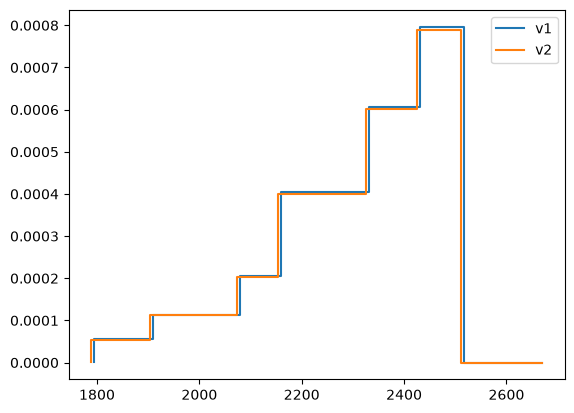

In [95]:
plt.step(qarra1[0],qarra1[1],label="v1")
plt.step(qarra2[0],qarra2[1],label="v2")
plt.legend()
plt.pause(1)

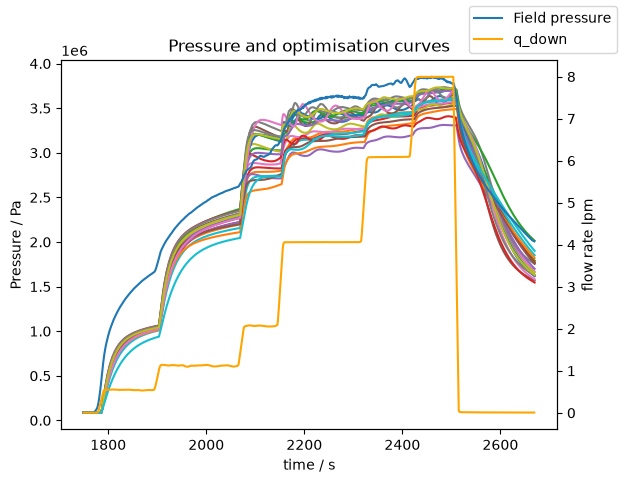

In [4]:
fig, ax= plt.subplots(sharex=True)
ax1=ax.twinx()
ax.set_ylabel("Pressure / Pa")
ax.set_xlabel("time / s")
ax1.set_ylabel("flow rate lpm")
for budle in iter_list:
    ax.plot(budle["timevalues"],budle["values"])
ax.plot(field_data["Zeit [s]"], field_data["Pint_downhole [MPa]_s"]*1e6,label="Field pressure",color='tab:blue' )
ax1.plot(field_data["Zeit [s]"], field_data["Q_downhole [lpm]_s"],label="q_down ",  color="orange")
#ax1.step(qarra2[0],qarra2[1],label="v2") #in m3/s

# for i in range(len(pro_v1)):
#     plt.axvline(pro_v1.loc[i,'T_s [s]'],ls="--",color="k")

# for j in range(len(pro_v2)):    
#     plt.axvline(pro_v2.loc[j,'T_s'],ls="--",color="tab:blue",label="q prot")
# ax.set_ylim(0,6e6)
plt.title("Pressure and optimisation curves")
fig.legend()
plt.pause(1)



In [7]:
for value in iter_list:
    print(value['metadata'])

{'pjack': 3455712.2450718903, 'wr': 246831.052035403, 'L': 1.6728488039929736, 'sf0': 0.0003907228019520621, 'iteration': 1, 'cost': np.float64(306890.05883674836)}
{'pjack': 3510126.716735057, 'wr': 446727.67114180827, 'L': 9.300261339515922, 'sf0': 0.0004507839742864068, 'iteration': 2, 'cost': np.float64(344744.1052784276)}
{'pjack': 3595233.438939629, 'wr': 362736.04825375904, 'L': 0.7614139996108344, 'sf0': 0.00040669204934182864, 'iteration': 3, 'cost': np.float64(280655.0026323251)}
{'pjack': 3442458.0091507225, 'wr': 412506.2453968995, 'L': 19.637132524471852, 'sf0': 0.00042114711097944127, 'iteration': 4, 'cost': np.float64(356501.76804920397)}
{'pjack': 3143761.0943623274, 'wr': 305537.1293851605, 'L': 1.669854370617541, 'sf0': 0.00045745915575871735, 'iteration': 5, 'cost': np.float64(454251.6081932639)}
{'pjack': 3408647.2524373108, 'wr': 198113.59668009233, 'L': 5.203295752748706, 'sf0': 0.0003457651676094343, 'iteration': 6, 'cost': np.float64(319249.44698589185)}
{'pjack

In [6]:
value['metadata'].keys()

dict_keys(['pjack', 'wr', 'L', 'iteration', 'cost'])

In [6]:
best_run=min(iter_list,key=lambda d: d['metadata']['cost'])
best_metadata=best_run["metadata"]
print(f"Mininum cost: {best_metadata['cost']}")
print(f"Optimal parameters: iteration={best_metadata['iteration']} pjack= {best_metadata['pjack']}, wr= {best_metadata['wr']}, L= {best_metadata['L']}, sf0= {best_metadata['sf0']}")


Mininum cost: 264747.0931739809
Optimal parameters: iteration=13 pjack= 3556341.7126441617, wr= 281129.6466165353, L= 0.40135132951552954, sf0= 0.0003549399331410328
